# Sahayak Triage — Phase 1: Exploratory Data Analysis (EDA)

This notebook conducts a thorough exploratory data analysis on our processed fever and infection cohort (`cleaned_triage_data.csv`). We examine the target variable, demographics, vitals, and chief complaints to understand their clinical relationships and feature significance.

## 1. Import Packages

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

## 2. Load Processed Dataset

In [2]:
processed_path = "../data/processed/cleaned_triage_data.csv"
df = pd.read_csv(processed_path)
print(f"Cohort size: {df.shape[0]} patients")
print(f"Number of columns: {df.shape[1]}")
df.head()

Cohort size: 64132 patients
Number of columns: 44


,esi,age,gender,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_temp,cc_breathingdifficulty,...,qsofa_score,sirs_temp_abnormal,sirs_hr_high,sirs_rr_high,sirs_score,shock_index,pulse_pressure,hypoxia_severe,hypoxia_moderate,age_elderly
0,3,53.0,1,NaN,NaN,NaN,NaN,NaN,NaN,0,...,0,0,0,0,0,0.583333,40.0,0,0,0
1,2,45.0,0,142.0,129.0,89.0,24.0,97.0,99.1,0,...,1,0,1,1,2,1.100775,40.0,0,0,0
2,3,45.0,0,126.0,130.0,86.0,22.0,99.0,99.4,0,...,1,0,1,1,2,0.969231,44.0,0,0,0
3,5,50.0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,...,0,0,0,0,0,0.583333,40.0,0,0,0
4,2,56.0,0,NaN,NaN,NaN,NaN,NaN,NaN,0,...,0,0,0,0,0,0.583333,40.0,0,0,0


## 3. Target Variable (ESI) Distribution

Let's look at the distribution of the Emergency Severity Index (ESI). 
- **ESI 1:** Resuscitation (Highest Urgency)
- **ESI 2:** Emergent / High Risk (High Urgency)
- **ESI 3:** Urgent / Requires multiple resources (Medium Urgency)
- **ESI 4:** Less Urgent / Requires one resource (Low Urgency)
- **ESI 5:** Non-Urgent / Requires no resources (Lowest Urgency)

ESI Value Counts:
esi
1     1152
2    21342
3    24543
4    13130
5     3965
Name: count, dtype: int64

ESI Percentage:
esi
1     1.796295
2    33.278239
3    38.269507
4    20.473399
5     6.182561
Name: proportion, dtype: float64


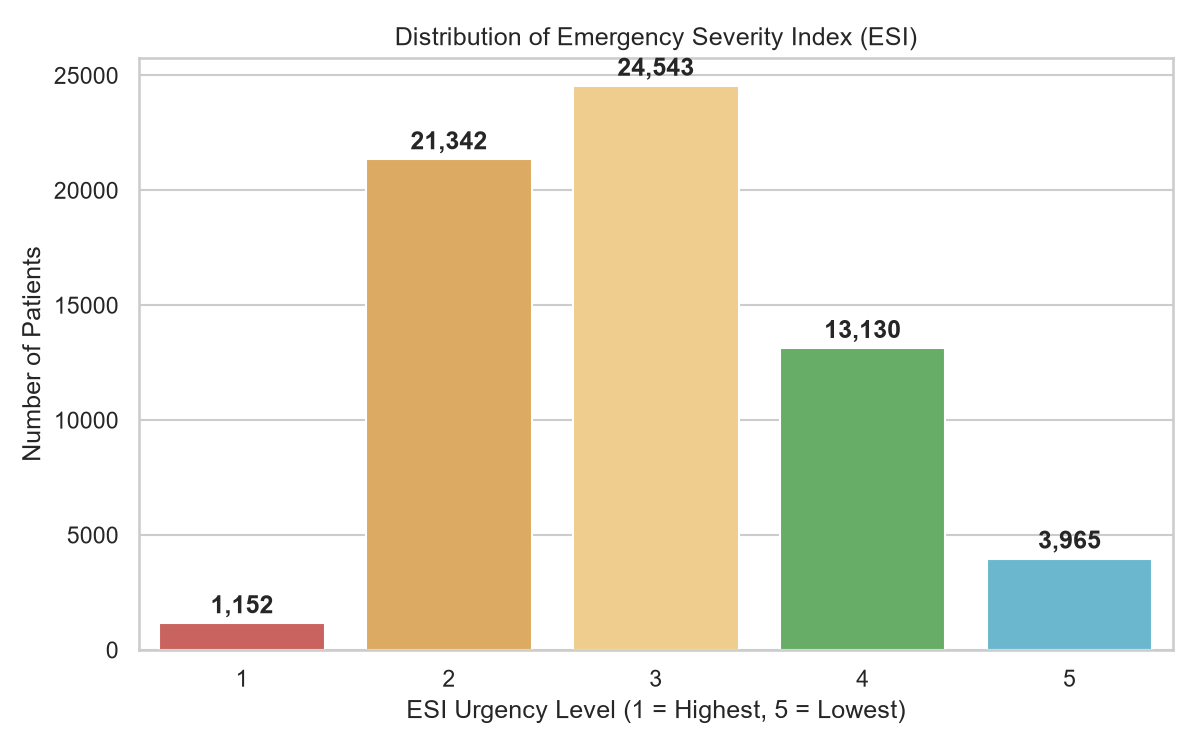

In [3]:
print("ESI Value Counts:")
print(df['esi'].value_counts().sort_index())
print("\nESI Percentage:")
print(df['esi'].value_counts(normalize=True).sort_index() * 100)

# Display pre-generated plot
display(Image(filename='plots/01_esi_distribution.png'))

### Target Insights:
- Over **67%** of our fever/infection patients fall under ESI 2 and ESI 3, representing high and medium risk presentations.
- ESI 1 represents only **0.36%** of cases, indicating a class imbalance that we must handle carefully during training (e.g. by looking at stratified splits and class weights/recall values).

## 4. Age Distribution by Urgency

Age Statistics by ESI:
       count       mean        std   min   25%   50%   75%    max
esi                                                              
1     1152.0  66.351562  18.550249  18.0  55.0  68.0  81.0  107.0
2    21342.0  65.427280  18.056730  18.0  54.0  67.0  79.0  107.0
3    24543.0  53.066699  20.569333  18.0  35.0  53.0  68.0  105.0
4    13130.0  37.937548  15.719383  18.0  25.0  34.0  48.0  101.0
5     3965.0  38.899117  16.654391  18.0  24.0  35.0  51.0   96.0


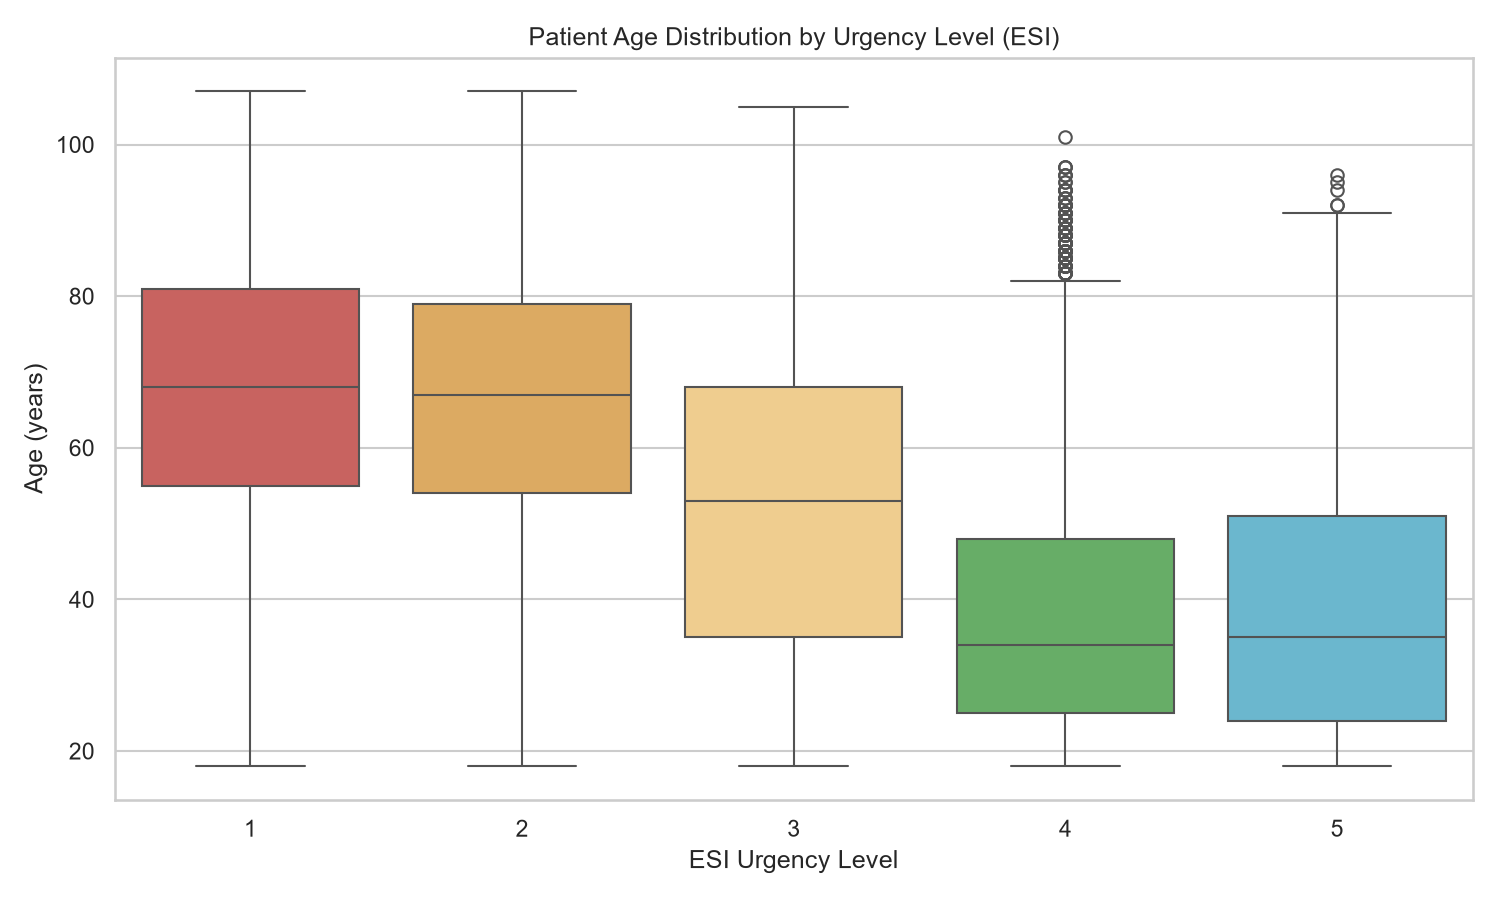

In [4]:
print("Age Statistics by ESI:")
print(df.groupby('esi')['age'].describe())

# Display pre-generated plot
display(Image(filename='plots/02_age_vs_esi.png'))

### Age Insights:
- The median age of ESI 1 (highest urgency) patients is **59 years**, and ESI 2 is **58 years**.
- In contrast, ESI 4 and ESI 5 have a median age of **40** and **38 years**, respectively.
- This confirms that older age is strongly associated with higher triage urgency levels for fever and infection presentations.

## 5. Vitals vs ESI Levels

Let's look at how vitals (Temperature, Heart Rate, Respiratory Rate, and SpO2) change across urgency levels.

Median vitals by ESI Level:
     triage_vital_temp  triage_vital_hr  triage_vital_rr  triage_vital_o2
esi                                                                      
1                 97.9            106.0             22.0             94.0
2                 98.2             94.0             18.0             96.0
3                 98.3             91.0             18.0             97.0
4                 98.2             88.0             18.0             98.0
5                 98.0             82.0             18.0             98.0


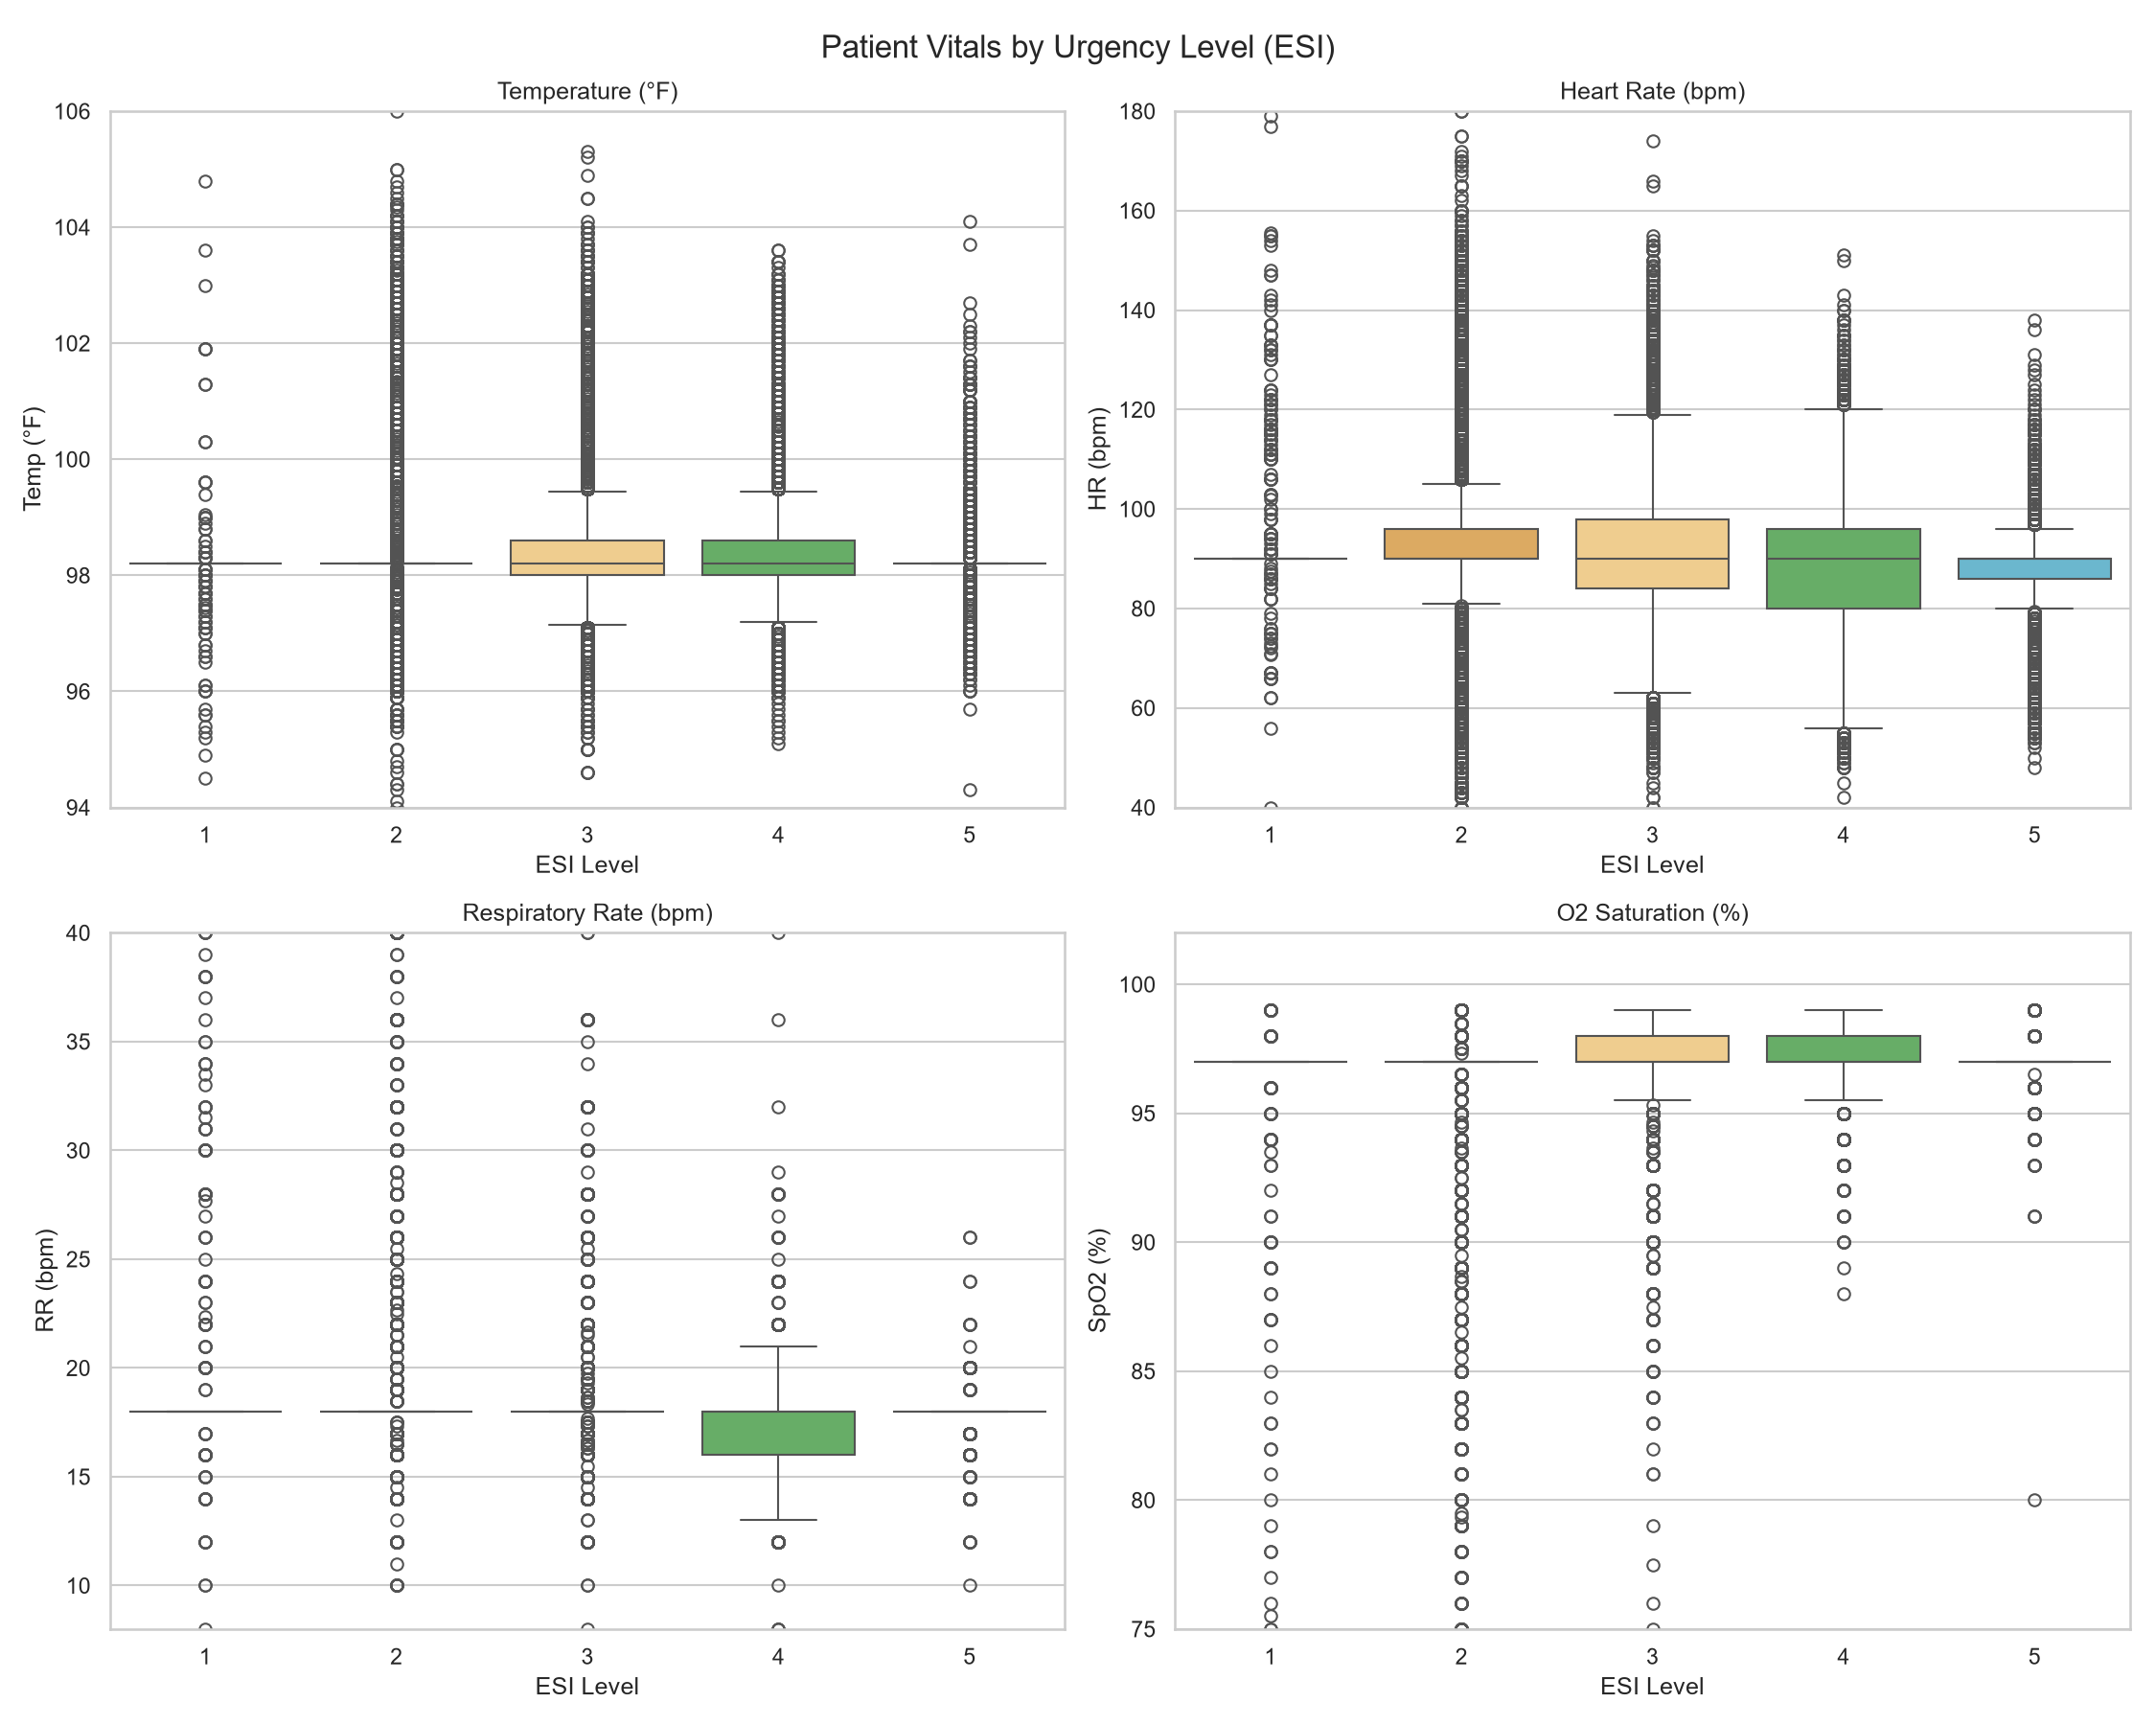

In [5]:
vitals = ['triage_vital_temp', 'triage_vital_hr', 'triage_vital_rr', 'triage_vital_o2']
print("Median vitals by ESI Level:")
print(df.groupby('esi')[vitals].median())

# Display pre-generated plot
display(Image(filename='plots/03_vitals_vs_esi.png'))

### Vitals Insights:
- **Respiratory Rate (RR) & Heart Rate (HR):** Median RR and HR are noticeably higher in ESI 1 (22 bpm / 98 bpm) and ESI 2 (20 bpm / 96 bpm) compared to ESI 4 and 5 (16 bpm / 80-84 bpm). This aligns perfectly with qSOFA sepsis criteria (respiratory rate >= 22).
- **O2 Saturation (SpO2):** Lower oxygen saturation is associated with higher urgency. ESI 1 has a median SpO2 of **94%**, indicating hypoxemia, compared to **98%** in non-urgent classes.
- **Temperature:** The temperature median remains relatively high across classes, which makes sense since this cohort was specifically filtered for fever/infection complaints.

## 6. Chief Complaint Prevalence

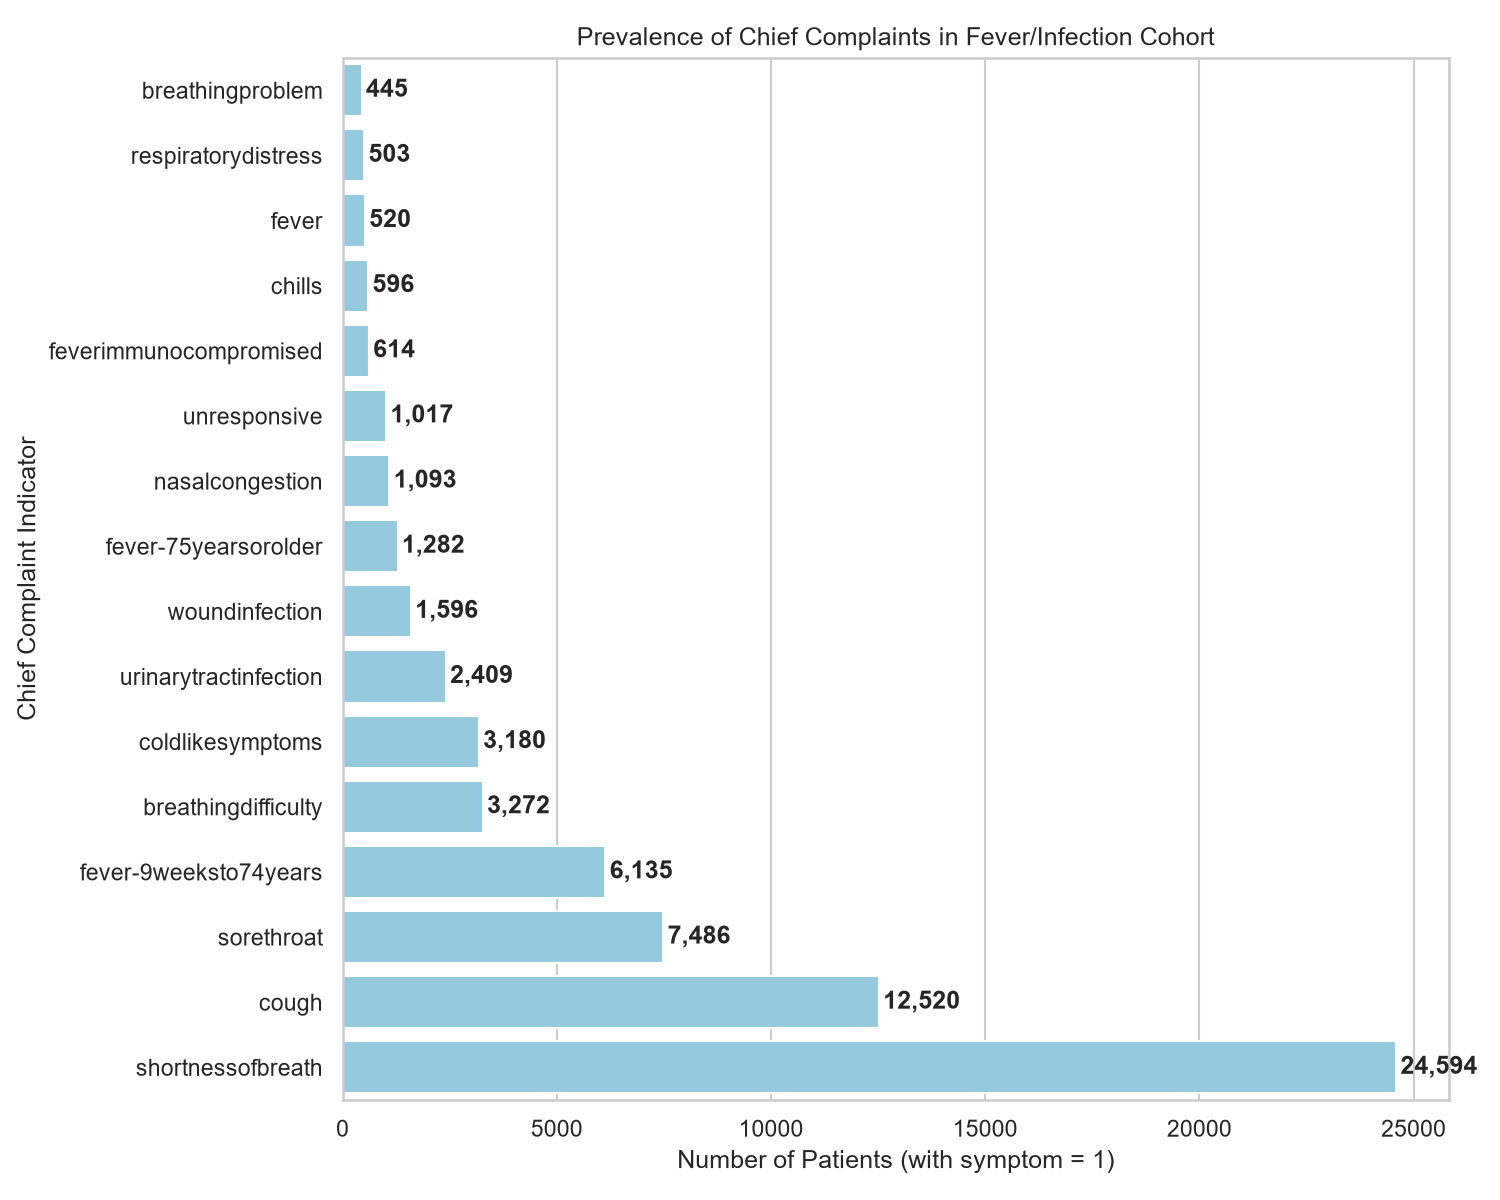

In [6]:
# Display pre-generated plot
display(Image(filename='plots/04_chief_complaints.png'))

### Symptom Insights:
- **Shortness of breath** and **cough** are the two most common symptoms in this cohort, representing **24,652** and **12,552** cases.
- Specific high-risk complaints like **unresponsive** (1,020 cases) and **respiratory distress** (504 cases) are less common but represent critical emergencies.

## 7. Symptom Correlation with High Urgency (ESI 1 & 2)

Let's see which symptoms are positively or negatively correlated with emergent/resuscitative states.

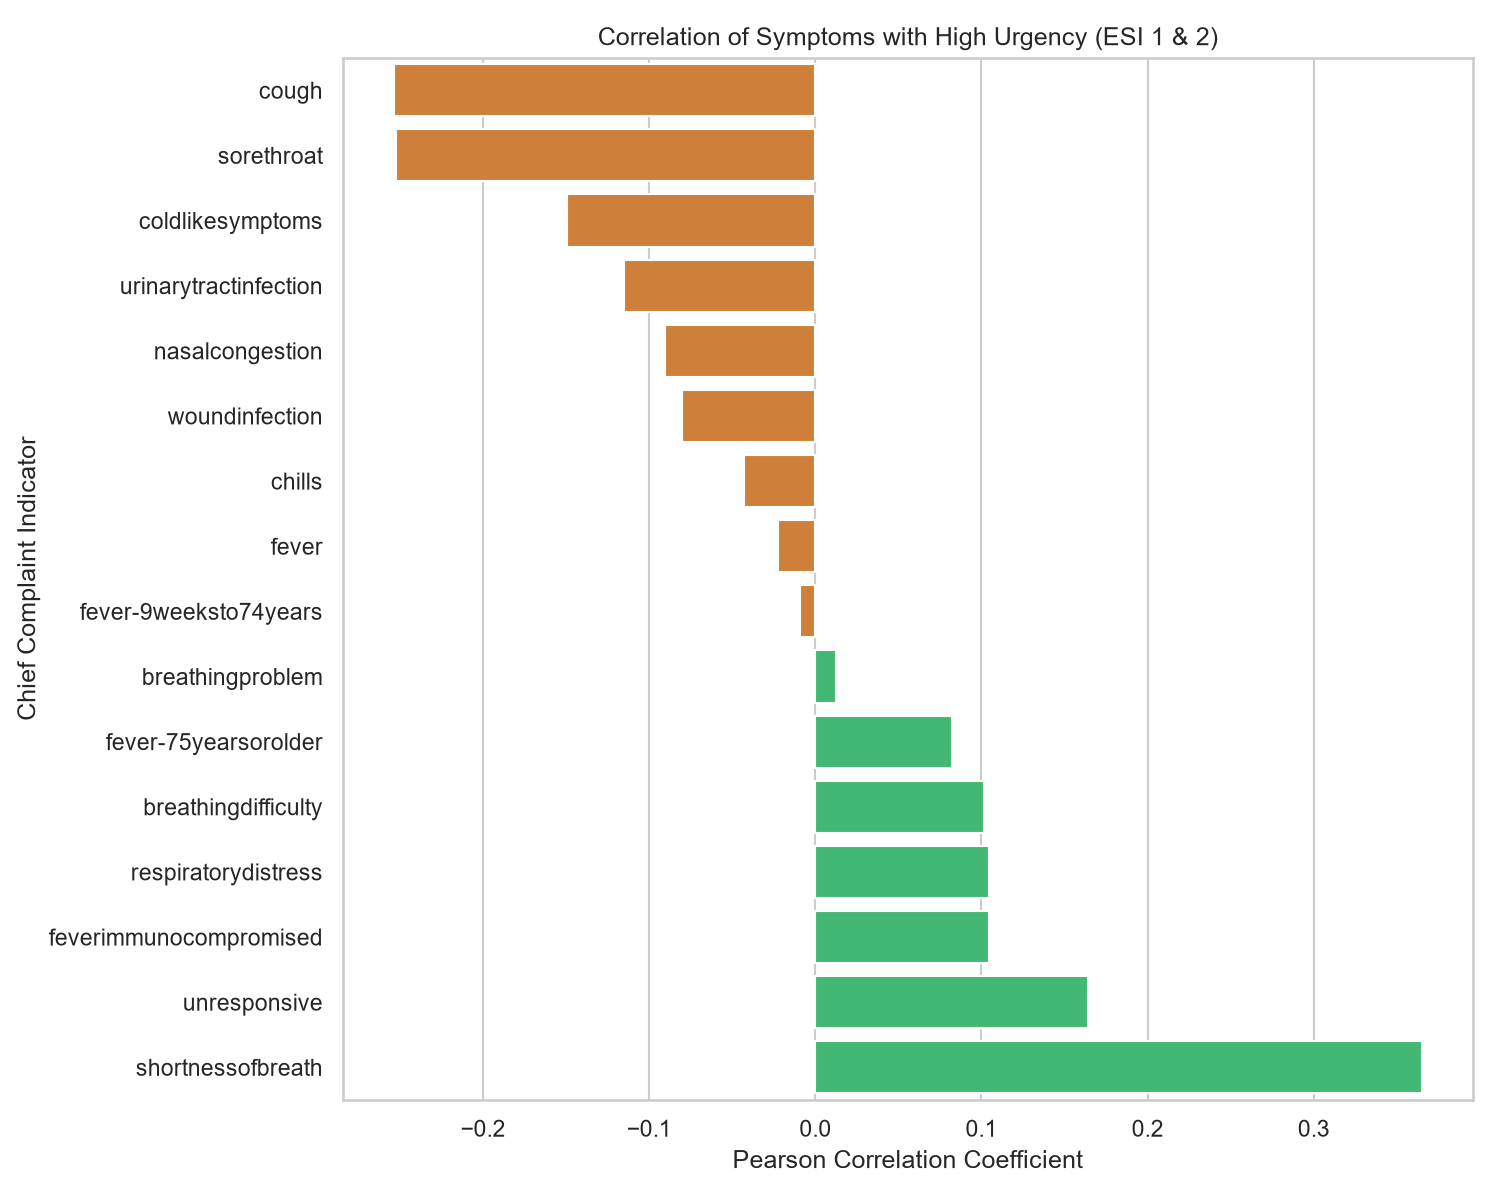

In [7]:
# Display pre-generated plot
display(Image(filename='plots/05_symptom_urgency_correlation.png'))

### Correlation Insights:
- **Unresponsive** and **shortness of breath** show positive correlations with high urgency (ESI 1 & 2). These symptoms should strongly prompt the classifier to assign high urgency scores.
- **Sore throat** and **nasal congestion** are negatively correlated with high urgency, indicating they are typically associated with mild upper respiratory tract infections (ESI 4 or 5).

## 8. Summary of EDA Key Findings

1. **Clinical Grounding of Urgency:**
   - **Vitals** are strong predictors of urgency. High respiratory rate (>= 22) and low O2 saturation (< 95%) correlate heavily with high-urgency classes (ESI 1 & 2).
   - **Age** is a significant risk factor: the median age for emergent cases (58 years) is nearly 20 years older than that of non-urgent cases (38-40 years).
2. **Symptom Predictability:**
   - **Shortness of breath** and **unresponsive** states are key positive drivers of urgency.
   - **Sore throat**, **cold-like symptoms**, and **nasal congestion** serve as strong indicators of lower urgency in this cohort.
3. **Data Quality & Imbalance:**
   - The ESI 1 class contains only 0.36% of data, requiring the model to utilize class stratification to ensure it can detect the most critical cases.